In [7]:
sys.path.append(r"../../../lib")

In [8]:
sys.path

['C:\\Program Files\\Python313\\python313.zip',
 'C:\\Program Files\\Python313\\DLLs',
 'C:\\Program Files\\Python313\\Lib',
 'C:\\Program Files\\Python313',
 '',
 'C:\\Program Files\\Python313\\Lib\\site-packages',
 '../../../lib']

In [9]:
from PIL import Image
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import torch

from build_sam import build_sam21_hiera_l
from automatic_mask_generator import SAM2AutomaticMaskGenerator
from lib.plotseg import plot_segmentations

In [4]:
swift = np.array(Image.open(r"../../images/Swift-GLX.jpg").convert("RGB"))
boat = np.array(Image.open(r"../../images/sa_9286.jpg").convert("RGB"))

swift.shape, boat.shape

((1536, 2048, 3), (1024, 1024, 3))

In [5]:
sam21 = build_sam21_hiera_l(checkpoint_path=r"../../bin/sam2.1_hiera_large.pt", device="cpu", apply_post_processing=False)

gen = SAM2AutomaticMaskGenerator(sam21)
gen_advanced = SAM2AutomaticMaskGenerator(
    model=sam21,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    box_nms_thresh=0.8,
    min_mask_region_area=25.0
)

In [10]:
msks_swift = gen.generate(swift)
msks_swift_adv = gen_advanced.generate(swift)

msks_boat = gen.generate(boat)
msks_boat_avd = gen_advanced.generate(boat)

C:\Users\90963425\OneDrive - Western Sydney University\PhD\code\models\sam2\sam2\sam2_image_predictor.py:334: UserWarning: No module named 'sam2'

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(low_res_masks, self._orig_hw[img_idx])


In [11]:
list(map(len, (msks_swift, msks_swift_adv, msks_boat, msks_boat_avd))) # well

[24, 42, 15, 55]

In [17]:
msks_swift = np.array([_["segmentation"] for _ in msks_swift])
msks_swift_adv = np.array([_["segmentation"] for _ in msks_swift_adv])
msks_boat = np.array([_["segmentation"] for _ in msks_boat])
msks_boat_avd = np.array([_["segmentation"] for _ in msks_boat_avd])

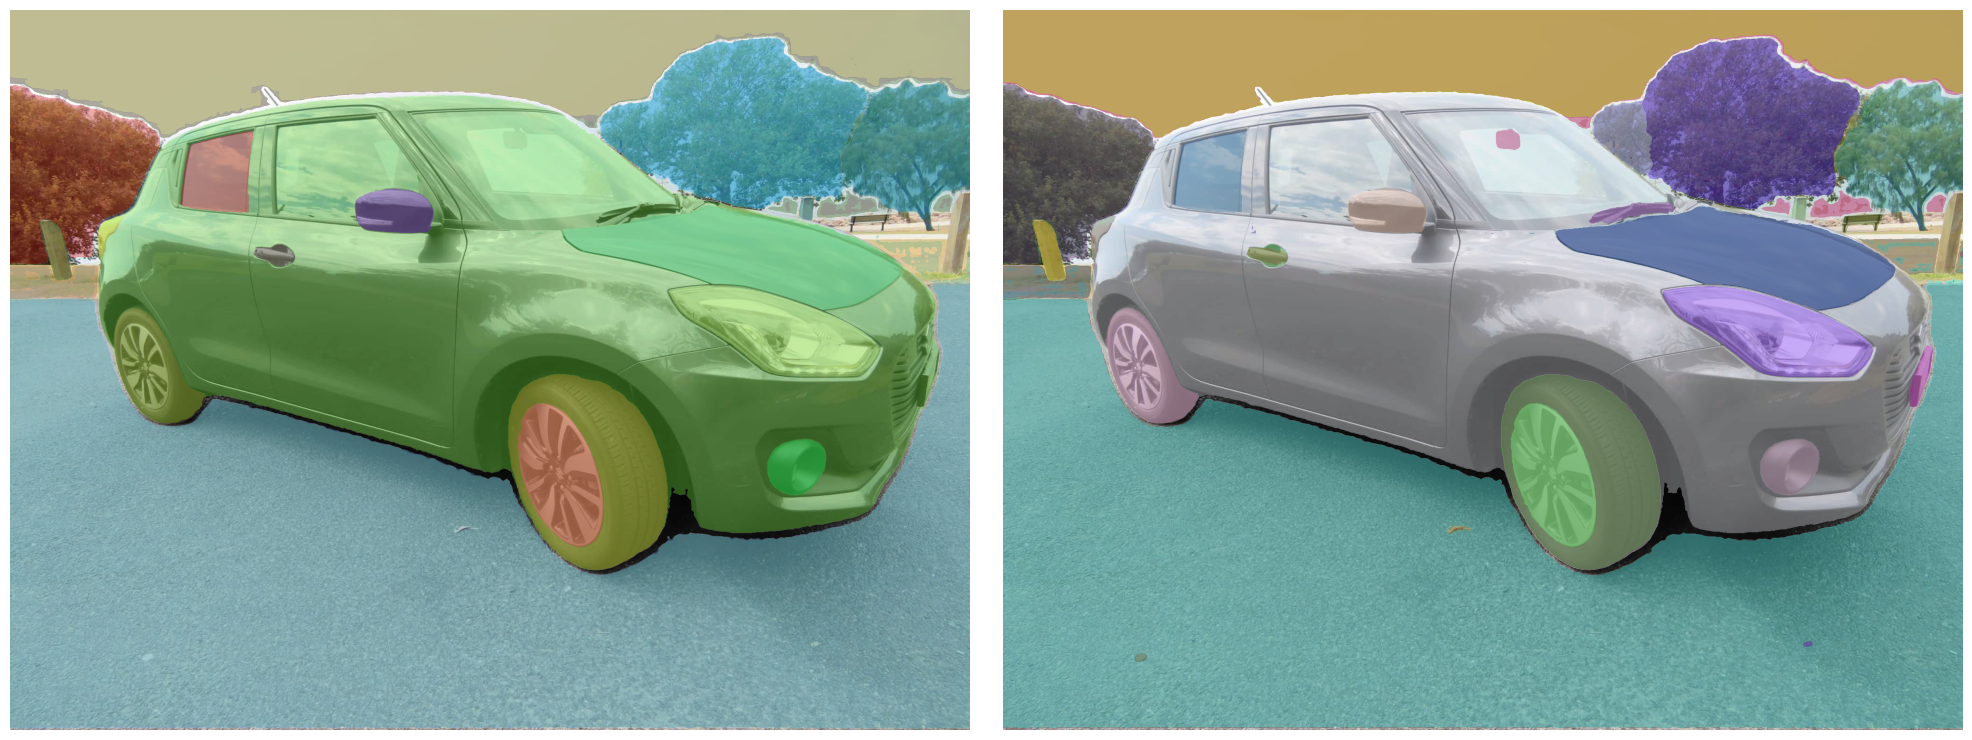

In [22]:
# not that impressed with the segmentation results though??? SAM did better, it seems compared to SAM 2.1
fig, (axes_l, axes_r) = plt.subplots(ncols=2)
fig.set_size_inches(20, 7.5)

axes_l.set_axis_off()
axes_l.imshow(swift)
plot_segmentations(ax=axes_l, masks=msks_swift, height=1536, width=2048)

axes_r.set_axis_off()
axes_r.imshow(swift)
plot_segmentations(ax=axes_r, masks=msks_swift_adv, height=1536, width=2048)

plt.tight_layout()
plt.show()

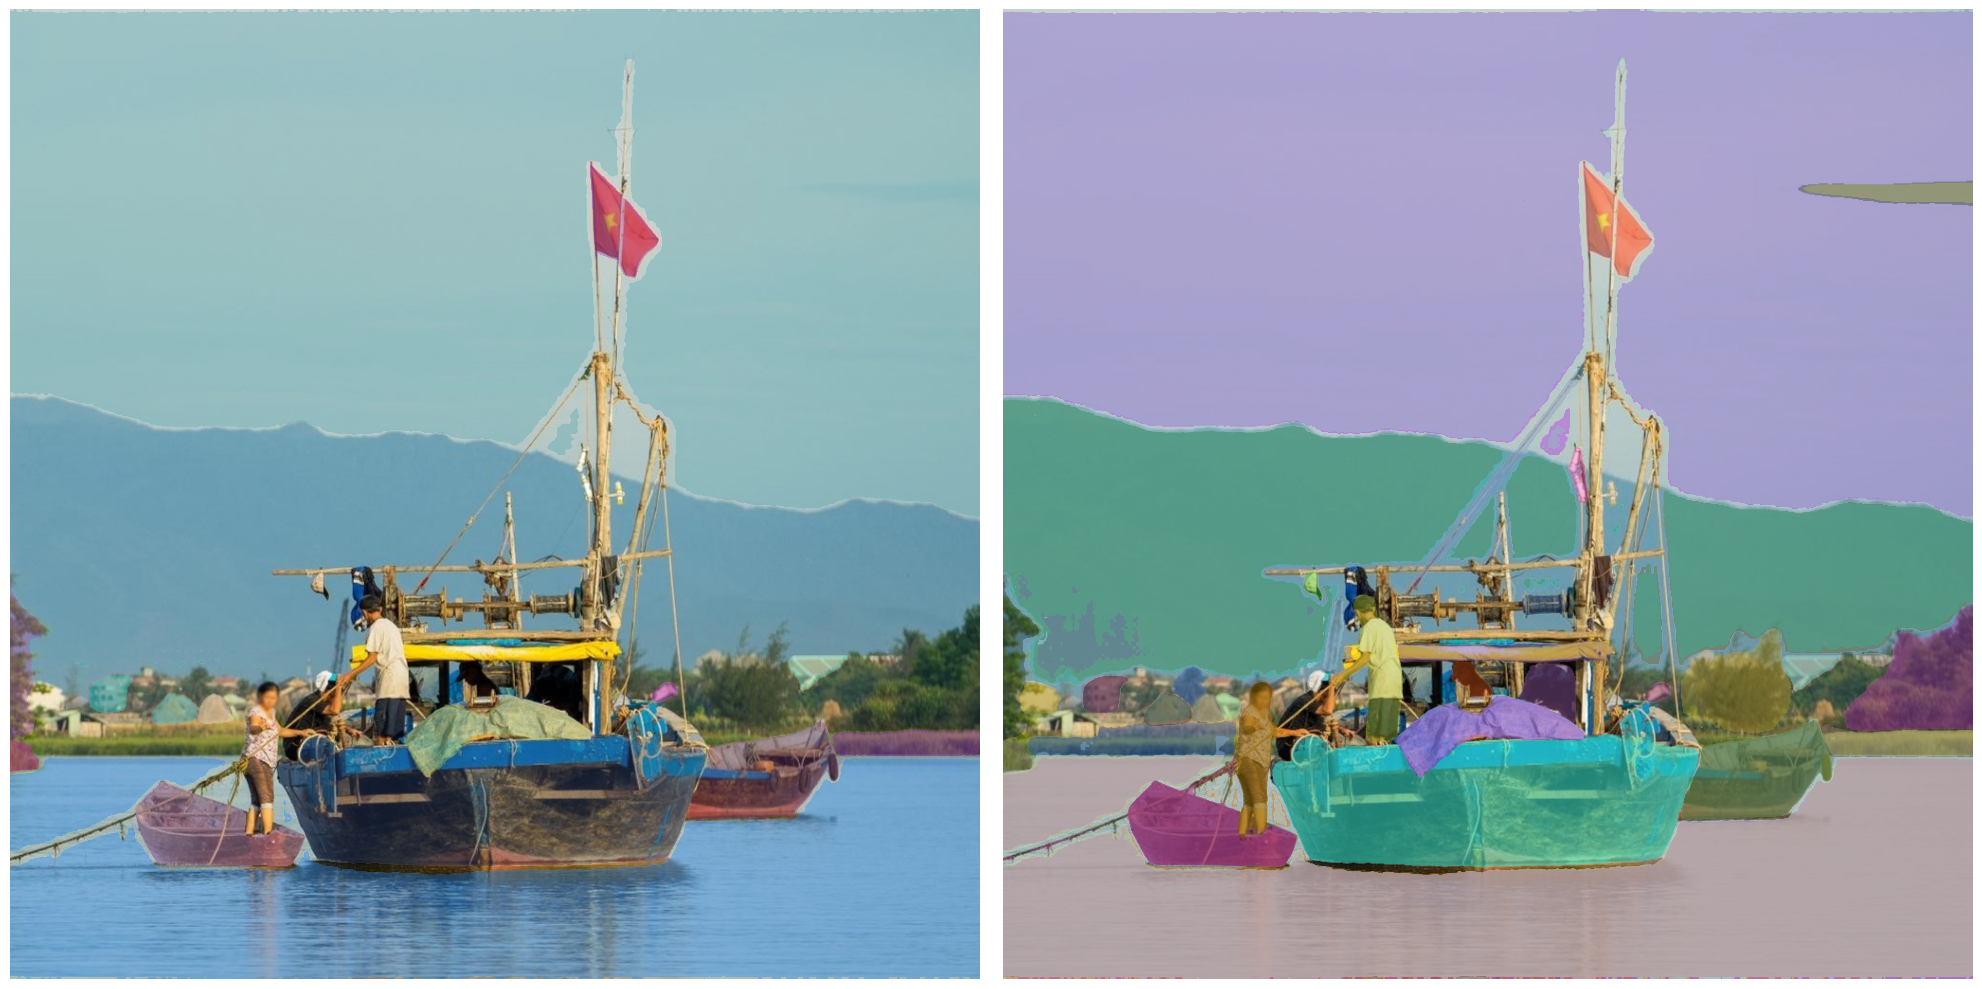

In [24]:
fig, (axes_l, axes_r) = plt.subplots(ncols=2)
fig.set_size_inches(20, 10)

axes_l.set_axis_off()
axes_l.imshow(boat)
plot_segmentations(ax=axes_l, masks=msks_boat, height=1024, width=1024)

axes_r.set_axis_off()
axes_r.imshow(boat)
plot_segmentations(ax=axes_r, masks=msks_boat_avd, height=1024, width=1024)

plt.tight_layout()
plt.show()